#PINNs for a 2D Problem
Our goal is to implement PINNs for solving a 2D static plate problem:
\begin{align}
\nabla.\sigma + p = 0\ \text{on}\ {\rm int}(\Omega),
\end{align}
where $\Omega = [0,L]\times [0,L]$. We assume that the plate is subject to the following boundary condition:
1. **Bottom**: $u_2(x_1,0)=0,\ \sigma_{12}(x_1,0)=0$;
2. **Left**: $u_1(0,x_2)=0,\ \sigma_{12}(0,x_2)=0$;
3. **Top**: $\sigma_{22}(x_1,L)=0,\ \sigma_{12}(x_1,L)=0$;
4. **Right**: $\sigma_{11}(L,x_2)=t,\ \sigma_{12}(L,x_2)=0$.

<p align="center">
<img src="https://drive.google.com/uc?id=1XN_D-7JL003f1AH3xgmcPVea873EEZ8m", width="300">

Here, $t$ is a uniform traction applied to the plate's right edge. The analytical solution for the problem is given by the displacement field
\begin{align}
u = [\tfrac{t}{E}x_1,\ -\tfrac{\nu t}{E}x_2]^\top
\end{align}

This example is taken from the following reference:

L. Herrmann, et al., *Deep Learning in Computational Mechanics: An Introductory Course*. Cham: Springer Nature Switzerland, 2025.

Installing the `equinox` package:

In [ ]:
!pip install equinox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.4 MB/s eta 0:00:00


Imports:

In [ ]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt

##PINN
Initialization key:

In [ ]:
key = jax.random.PRNGKey(42)
key, init_key = jax.random.split(key)

As the key step, we approximate the displacement field by a feedforward neural network, $u(x)\approx {\rm NN}(x;\theta)$, where $x=[x_1,x_2]^\top$:

In [ ]:
pinn = eqx.nn.MLP(
    in_size=2,
    out_size=2,
    width_size=10,
    depth=4,
    activation=jax.nn.tanh,
    key=init_key
)

###Enforcing Dirichlet Boundary Conditions


In [ ]:
def pinn_enforced(network, x):
  return x * network(x)

In [ ]:
pinn_enforced(pinn, jnp.array([1.0,0.0]))

Array([0.32289535, 0.        ], dtype=float32)

Let's evaluate network's initial output:

In [ ]:
x1_data = jnp.linspace(0.0, 1.0, 100)
x2_data = jnp.linspace(0.0, 1.0, 100)
X1_data, X2_data = jnp.meshgrid(x1_data, x2_data)
print(X1_data.shape)
print(X2_data.shape)

# flatten the grid
X1X2_Data = jnp.stack([X1_data.ravel(), X2_data.ravel()], axis=1)
print(X1X2_Data.shape)

(100, 100)
(100, 100)
(10000, 2)


(10000, 2)


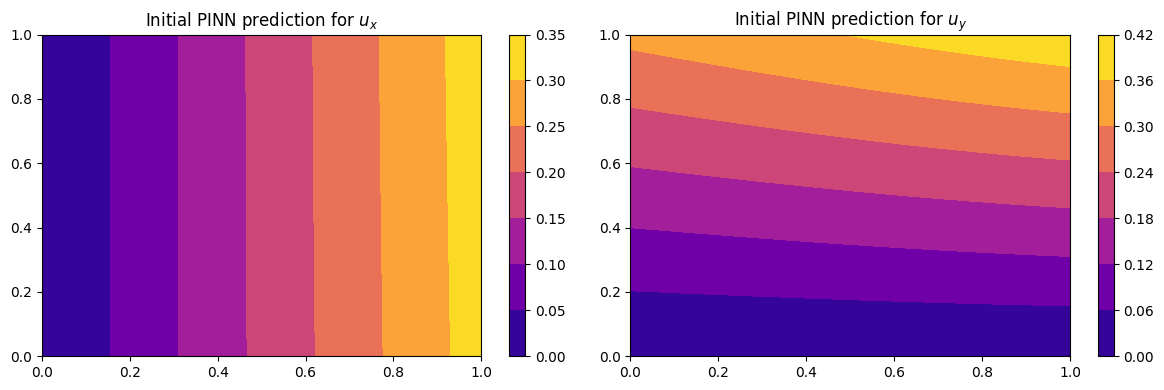

In [ ]:
U_init = jax.vmap(pinn_enforced, in_axes=(None,0))(pinn, X1X2_Data)
print(U_init.shape)

Ux_init = U_init[:,0]
Uy_init = U_init[:,1]

plt.figure(figsize=(12,4))
# Visualize the x-component
plt.subplot(1,2,1)
plt.contourf(X1_data, X2_data, Ux_init.reshape(100,100),cmap='plasma')
plt.colorbar()
plt.title(r'Initial PINN prediction for $u_x$')

# Visualize the y-component
plt.subplot(1,2,2)
plt.contourf(X1_data, X2_data, Uy_init.reshape(100,100),cmap='plasma')
plt.colorbar()
plt.title('Initial PINN prediction for $u_y$')
plt.tight_layout()
plt.show()

##Strain Tensor
We define a function that calculates the strain tesnor using the *enforced* version of a given NN: $$\epsilon = \frac{1}{2}\left(\nabla u + \nabla u^\top\right)$$

In [ ]:
def strainTensor(network, x):
  u_grad = jax.jacrev(pinn_enforced, argnums=1)(network, x) # displacement gradient: shape (2,2), u_grad[i,j] = du_i/dx_j
  e = 0.5 * (u_grad + u_grad.T) # shape (2,2)
  return e

In [ ]:
strainTensor(pinn, jnp.array([0.5,0.5]) )

Array([[0.32516772, 0.02368946],
       [0.02368946, 0.36217213]], dtype=float32)

(10000, 2, 2)


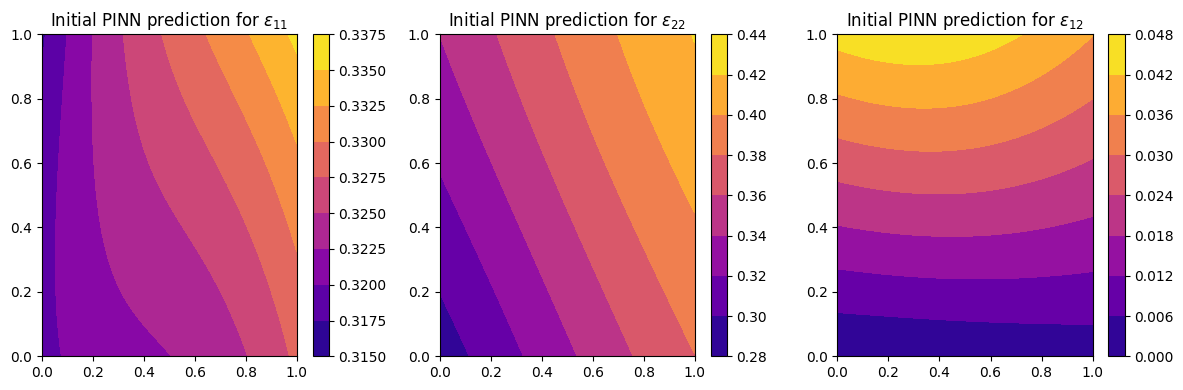

In [ ]:
init_strain = jax.vmap(lambda x: strainTensor(pinn, x))(X1X2_Data)
print(init_strain.shape)
init_e11 = init_strain[:,0,0]
init_e22 = init_strain[:,1,1]
init_e12 = init_strain[:,0,1]

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.contourf(X1_data, X2_data, init_e11.reshape(100,100), cmap='plasma')
plt.colorbar()
plt.title(r'Initial PINN prediction for $\epsilon_{11}$')

plt.subplot(1,3,2)
plt.contourf(X1_data, X2_data, init_e22.reshape(100,100), cmap='plasma')
plt.colorbar()
plt.title(r'Initial PINN prediction for $\epsilon_{22}$')

plt.subplot(1,3,3)
plt.contourf(X1_data, X2_data, init_e12.reshape(100,100), cmap='plasma')
plt.colorbar()
plt.title(r'Initial PINN prediction for $\epsilon_{12}$')
plt.tight_layout()
plt.show()

##Contitutive Equation - Elasticity Tensor
Given Young's modulus $E$ and the Poisson ratio $\nu$ under the plane stress approximation, we have
\begin{align}
&\begin{bmatrix}
\sigma_{11} \\ \sigma_{22} \\ \sigma_{12}
\end{bmatrix} = {\rm C} \begin{bmatrix}
\epsilon_{11} \\ \epsilon_{22} \\ \epsilon_{12}
\end{bmatrix}\\
&{\rm C} = \frac{E}{1-\nu^2}\begin{bmatrix}
1 & \nu & 0\\
\nu & 1 & 0\\
0 & 0 & 1-\nu
\end{bmatrix}
\end{align}

In [ ]:
# Elasticity Tensor in Voigt Notation
E = 1
nu = 0.3
Elasticity_Tensor = (E/(1-nu**2))*jnp.array([[1.0, nu, 0.0],
                                             [nu, 1.0, 0.0],
                                             [0.0, 0.0, 1.0-nu]])

We define a function that returns the stress tensor using the above constitutive equation:

In [ ]:
def stressTensor(network, x):
  # Strain tensor
  epsilon = strainTensor(network, x) # shape (2,2)
  # Voigt form
  epsilon_Voigt = jnp.array([epsilon[0,0], epsilon[1,1], epsilon[0,1]]) # shape (3,)
  sigma_Voigt = Elasticity_Tensor @ epsilon_Voigt
  sigma = jnp.array([[sigma_Voigt[0], sigma_Voigt[2]],[sigma_Voigt[2], sigma_Voigt[1]]])
  return sigma

In [ ]:
stressTensor(pinn, jnp.array([0.5,0.5]))

Array([[0.4767246 , 0.01822266],
       [0.01822266, 0.50518954]], dtype=float32)

Let's evaluate the initial PINN stress field:

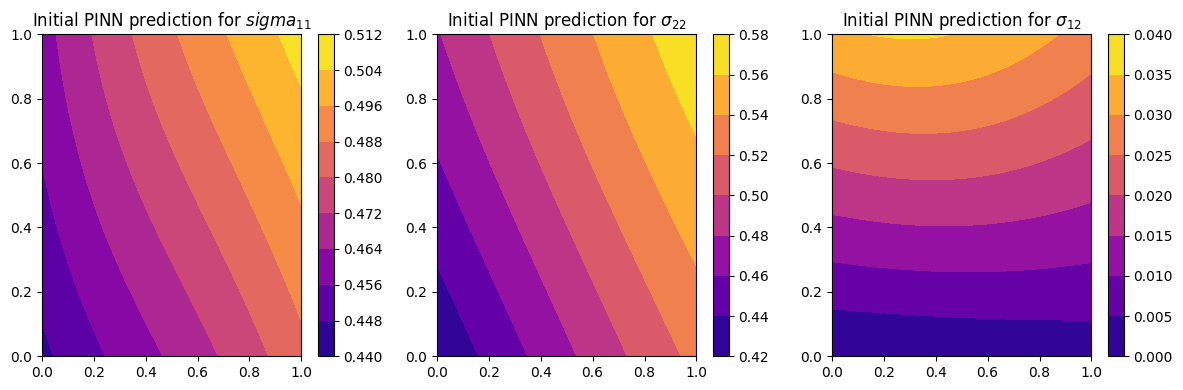

In [ ]:
from typing import ChainMap
init_stress = jax.vmap(lambda x: stressTensor(pinn, x))(X1X2_Data)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.contourf(X1_data, X2_data, init_stress[:,0,0].reshape(100,100), cmap='plasma')
plt.title(r'Initial PINN prediction for $sigma_{11}$')
plt.colorbar()

plt.subplot(1,3,2)
plt.contourf(X1_data, X2_data, init_stress[:,1,1].reshape(100,100), cmap='plasma')
plt.title(r'Initial PINN prediction for $\sigma_{22}$')
plt.colorbar()

plt.subplot(1,3,3)
plt.contourf(X1_data, X2_data, init_stress[:,0,1].reshape(100,100), cmap='plasma')
plt.title(r'Initial PINN prediction for $\sigma_{12}$')
plt.colorbar()
plt.tight_layout()
plt.show()

##Loss Function
### PDE loss
We need to calculate the residuum of the balance equation: $$r(x)=\nabla. \sigma(x) + p(x)$$

Note that $p(x)\equiv 0$ in our particular example.

In [ ]:
def PDE_residue(network, x):
  sigma_grad = jax.jacfwd(stressTensor, argnums=1)(network, x)
  sigma_div0 = sigma_grad[0,0,0] + sigma_grad[0,1,1]
  sigma_div1 = sigma_grad[1,0,0] + sigma_grad[1,1,1]
  sigma_div = jnp.array([sigma_div0, sigma_div1])
  return sigma_div

We verify the divergence calculation of the stress tensor:

In [ ]:
def linear_model(x):
    ux = 0.1
    uy = -0.05
    return jnp.array([ux, uy])

PDE_residue(linear_model, jnp.array([-0.5,0.5]))

Array([0., 0.], dtype=float32)

In [ ]:
sigma_grad0 = PDE_residue(pinn, jnp.array([0.5,0.5]))
sigma_grad0.shape

(2,)

In [ ]:
init_residual = jax.vmap(PDE_residue, in_axes=(None, 0))(pinn, X1X2_Data)

In [ ]:
print(init_residual.shape)

(10000, 2)


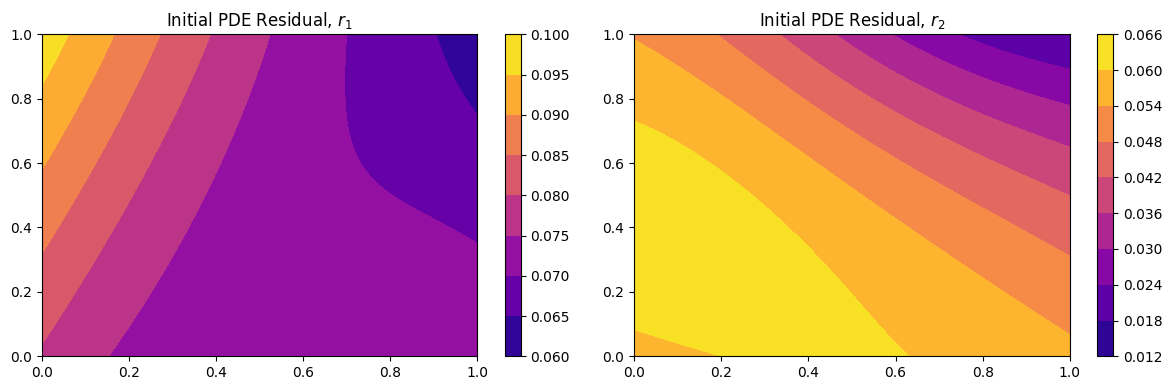

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.contourf(X1_data, X2_data, init_residual[:,0].reshape(100,100), cmap='plasma')
plt.colorbar()
plt.title(r'Initial PDE Residual, $r_1$')

plt.subplot(1,2,2)
plt.contourf(X1_data, X2_data, init_residual[:,1].reshape(100,100), cmap='plasma')
plt.colorbar()
plt.tight_layout()
plt.title(r'Initial PDE Residual, $r_2$')

plt.show()

Let's generate **collocation points** inside the domain:

In [ ]:
key, x1_key, x2_key = jax.random.split(key, 3)
N_collocation = 20
x1_collocation = jax.random.uniform(x1_key, shape=(N_collocation,),
                                    minval=0.0+1e-04, maxval=1.0-1e-04)
x2_collocation = jax.random.uniform(x2_key, shape=(N_collocation,),
                                    minval=0.0+1e-04, maxval=1.0-1e-04)
X1_Collocation, X2_Collocation = jnp.meshgrid(x1_collocation, x2_collocation)
print(X1_Collocation.shape)
print(X2_Collocation.shape)
# shape (N, 2) to be fed to the pinn
X1X2_Collocation = jnp.stack([X1_Collocation.ravel(), X2_Collocation.ravel()], axis=1)
print(X1X2_Collocation.shape)

(20, 20)
(20, 20)
(400, 2)


Now, the $L_2$ PDE loss:

In [ ]:
def PDE_loss(network):
  res = jax.vmap(PDE_residue, in_axes=(None, 0))(network, X1X2_Collocation)
  return 0.5 * jnp.mean(jnp.sum(res**2, axis=1))

In [ ]:
PDE_loss(pinn)

Array(0.00421949, dtype=float32)

###Boundary Loss

In [ ]:
X_bottom = jnp.stack([x1_collocation, jnp.zeros(N_collocation,)], axis = 1)
s = jax.vmap(stressTensor, in_axes=(None, 0))(pinn, X_bottom)

In [ ]:
traction = 1 # traction at the right edge
def BC_loss(network):
  #Bottom edge
  X_bottom = jnp.stack([x1_collocation, jnp.zeros(N_collocation,)], axis=1)
  s_bottom = jax.vmap(stressTensor, in_axes=(None, 0))(network, X_bottom)
  sigma12_bottom = s_bottom[:,0,1]
  loss_bottom = 0.5 * jnp.mean(sigma12_bottom**2)

  #Left edge
  X_left = jnp.stack([jnp.zeros(N_collocation,), x2_collocation], axis=1)
  s_left = jax.vmap(stressTensor, in_axes=(None, 0))(network, X_left)
  sigma12_left = s_left[:,0,1]
  loss_left = 0.5 * jnp.mean(sigma12_left**2)

  #Top edge
  X_top = jnp.stack([x1_collocation, jnp.ones(N_collocation,)], axis=1)
  s_top = jax.vmap(stressTensor, in_axes=(None, 0))(network, X_top)
  sigma22_top = s_top[:,1,1]
  sigma12_top = s_top[:,0,1]
  loss_top = 0.5 * jnp.mean(sigma22_top**2) + 0.5 * jnp.mean(sigma12_top**2)

  #Right edge
  X_right = jnp.stack([jnp.ones(N_collocation,), x2_collocation], axis=1)
  s_right = jax.vmap(stressTensor, in_axes=(None, 0))(network, X_right)
  sigma11_right = s_right[:,0,0]
  sigma12_right = s_right[:,0,1]
  loss_right = 0.5 * jnp.mean((sigma11_right - traction)**2) + 0.5 * jnp.mean(sigma12_right**2)

  total_bc_loss = loss_bottom + loss_left + loss_right + loss_top
  return total_bc_loss

In [ ]:
print(BC_loss(pinn))

0.26820272


Comparing the magnitudes of two types of loss:

In [ ]:
L0_PDE = PDE_loss(pinn)
L0_BC = BC_loss(pinn)
print(L0_PDE)
print(L0_BC)

0.00421949
0.26820272


###Total Loss

In [ ]:
def Total_loss(network):
  return PDE_loss(network)/(L0_PDE+1e-12) + BC_loss(network)/(L0_BC+1e-12)

In [ ]:
print(Total_loss(pinn))

2.0


We define an optimizer in `optax`:

In [ ]:
l_rate = 1e-03
N_epochs = 1000
optimizer = optax.adam(l_rate)
opt_state = optimizer.init(eqx.filter(pinn, eqx.is_array))

We build a function that will update the PINN at each training step:

In [ ]:
@eqx.filter_jit
def make_update(network, state):
  loss, grads = eqx.filter_value_and_grad(Total_loss)(network)
  model_updates, new_state = optimizer.update(grads, state, network)
  new_network = eqx.apply_updates(network, model_updates)

  return new_network, new_state, loss

Training Loop:

In [ ]:
loss_history = []

for epoch in range(N_epochs):
  pinn, opt_state, loss = make_update(pinn, opt_state)
  loss_history.append(loss)
  if epoch % 100 == 0:
    print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 2.0
Epoch 100, Loss: 0.07911038398742676
Epoch 200, Loss: 0.002778012538328767
Epoch 300, Loss: 0.0014637162676081061
Epoch 400, Loss: 0.0010136585915461183
Epoch 500, Loss: 0.0007250641938298941
Epoch 600, Loss: 0.0005323816440068185
Epoch 700, Loss: 0.00039964535972103477
Epoch 800, Loss: 0.0003055651322938502
Epoch 900, Loss: 0.0002373184252064675


Text(0, 0.5, 'Loss')

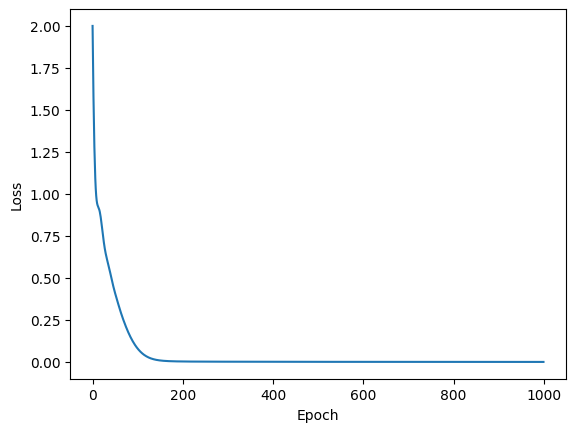

In [ ]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")

In [ ]:
def exactSol(x):
  u_exact = jnp.stack([x[:,0] * traction/E, x[:,1] * (-nu*traction/E)], axis=1) # shape (N,2)
  return u_exact

Visualize the solution:

(10000, 2)


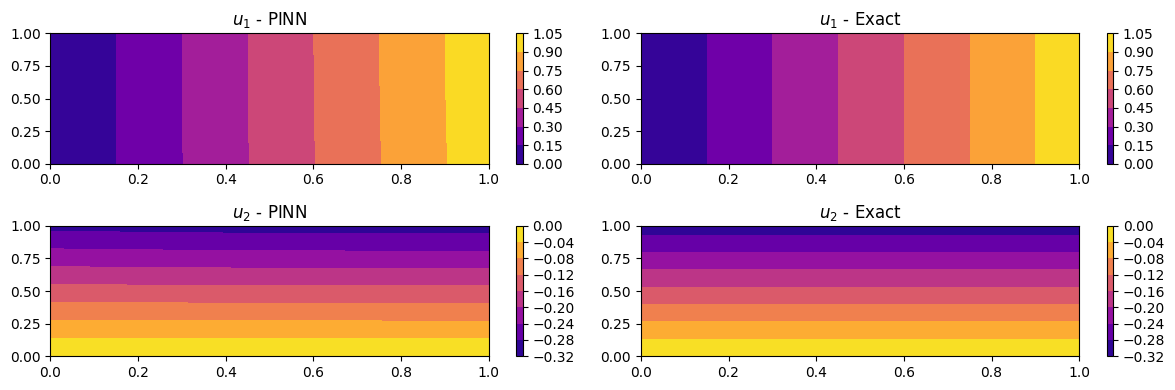

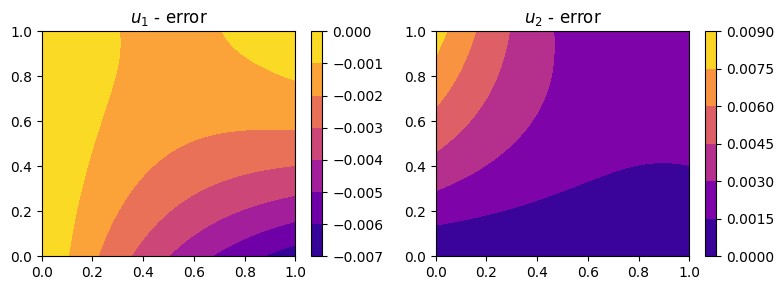

In [ ]:
U_pinn = jax.vmap(pinn_enforced, in_axes=(None,0))(pinn, X1X2_Data)
print(U_pinn.shape)
U_exact = exactSol(X1X2_Data)

plt.figure(figsize=(12,4))
plt.subplot(2,2,1)
plt.contourf(X1_data, X2_data, U_pinn[:,0].reshape(100,100), cmap='plasma')
plt.colorbar()
plt.title(r'$u_1$ - PINN')

plt.subplot(2,2,2)
plt.contourf(X1_data, X2_data, U_exact[:,0].reshape(100,100), cmap='plasma')
plt.colorbar()
plt.title(r'$u_1$ - Exact')

plt.subplot(2,2,3)
plt.contourf(X1_data, X2_data, U_pinn[:,1].reshape(100,100),cmap='plasma')
plt.colorbar()
plt.title(r'$u_2$ - PINN')

plt.subplot(2,2,4)
plt.contourf(X1_data, X2_data, U_exact[:,1].reshape(100,100), cmap='plasma')
plt.colorbar()
plt.title(r'$u_2$ - Exact')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.contourf(X1_data, X2_data, U_pinn[:,0].reshape(100,100)-U_exact[:,0].reshape(100,100), cmap='plasma')
plt.colorbar()
plt.title(r'$u_1$ - error')

plt.subplot(1,2,2)
plt.contourf(X1_data, X2_data, U_pinn[:,1].reshape(100,100)-U_exact[:,1].reshape(100,100), cmap='plasma')
plt.colorbar()
plt.title(r'$u_2$ - error')
plt.tight_layout()

###Strain & Stress Fields
Exact values:
\begin{align}
&\epsilon_{11} = \frac{t_0}{E},\ \epsilon_{22} = \frac{-\nu t_0}{E},\ \epsilon_{12} = 0\\
&\sigma_{11} = \frac{E}{1-\nu^2}(\epsilon_{11} + \nu \epsilon_{22})=t_0,\ \sigma_{22} = \frac{E}{1-\nu^2}(\nu \epsilon_{11} +  \epsilon_{22})=0,\ \sigma_{12} = \frac{E}{1-\nu^2}(1-\nu)\epsilon_{12}=0
\end{align}
Recall that we work with the normalized parameters $E=1$, $\nu=0.3$, and $t_0=1$.

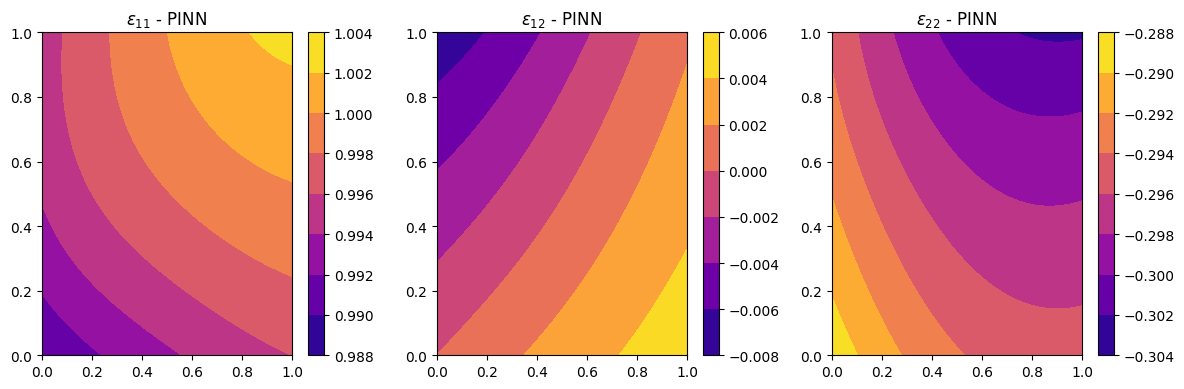

In [ ]:
strain_pinn = jax.vmap(lambda x: strainTensor(pinn, x))(X1X2_Data)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.contourf(X1_data, X2_data, strain_pinn[:,0,0].reshape(100,100),cmap='plasma')
plt.colorbar()
plt.title(r"$\epsilon_{11}$ - PINN")

plt.subplot(1,3,2)
plt.contourf(X1_data, X2_data, strain_pinn[:,0,1].reshape(100,100),cmap='plasma')
plt.colorbar()
plt.title(r"$\epsilon_{12}$ - PINN")

plt.subplot(1,3,3)
plt.contourf(X1_data, X2_data, strain_pinn[:,1,1].reshape(100,100),cmap='plasma')
plt.colorbar()
plt.title(r"$\epsilon_{22}$ - PINN")
plt.tight_layout()
plt.show()

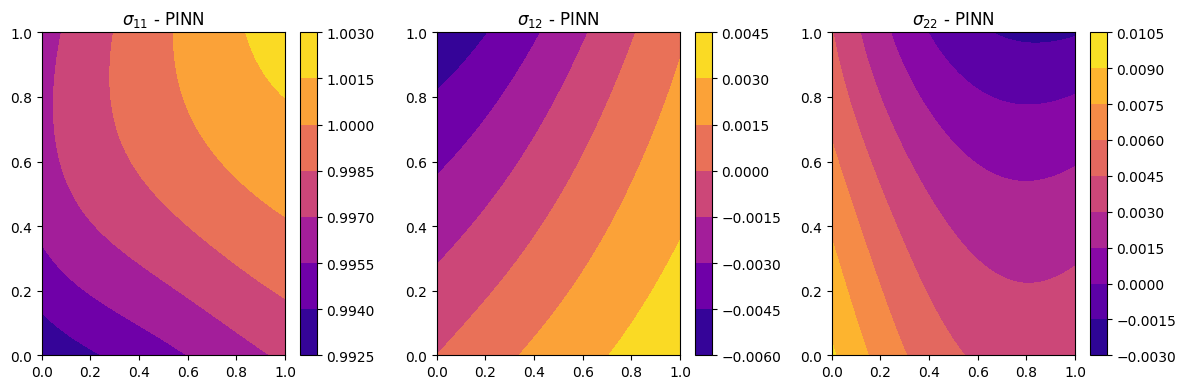

In [ ]:
stress_pinn = jax.vmap(lambda x: stressTensor(pinn, x))(X1X2_Data)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.contourf(X1_data, X2_data, stress_pinn[:,0,0].reshape(100,100),cmap='plasma')
plt.colorbar()
plt.title(r'$\sigma_{11}$ - PINN')

plt.subplot(1,3,2)
plt.contourf(X1_data, X2_data, stress_pinn[:,0,1].reshape(100,100),cmap='plasma')
plt.colorbar()
plt.title(r'$\sigma_{12}$ - PINN')

plt.subplot(1,3,3)
plt.contourf(X1_data, X2_data, stress_pinn[:,1,1].reshape(100,100),cmap='plasma')
plt.colorbar()
plt.title(r'$\sigma_{22}$ - PINN')
plt.tight_layout()
plt.show()